In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd

In [7]:
titanic = pd.read_csv("titanic_clase4.csv")
titanic

,nombre,sobrevivio,clase,sexo,edad,tarifa,embarcacion,cabina
0,Jack Dawson,0,3,male,20.0,7.25,S,NaN
1,Rose DeWitt,1,1,female,17.0,512.33,C,B57
2,John Smith,0,2,male,35.0,13.00,S,NaN
3,Mary Johnson,1,1,female,28.0,76.29,C,C85
4,Thomas Brown,0,3,male,NaN,8.05,S,NaN
5,Elisabeth Jones,1,1,female,45.0,35.50,S,C103
6,William Davis,0,3,male,23.0,7.92,Q,NaN
7,Sarah Wilson,1,2,female,31.0,21.00,S,NaN
8,James Miller,0,3,male,NaN,7.75,Q,NaN
9,Emma Moore,1,1,female,22.0,151.55,S,B45


In [8]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nombre       31 non-null     str    
 1   sobrevivio   31 non-null     int64  
 2   clase        31 non-null     int64  
 3   sexo         31 non-null     str    
 4   edad         27 non-null     float64
 5   tarifa       31 non-null     float64
 6   embarcacion  31 non-null     str    
 7   cabina       11 non-null     str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.1 KB


In [9]:
titanic.describe()

,sobrevivio,clase,edad,tarifa
count,31.000000,31.000000,27.000000,31.000000
mean,0.516129,2.129032,33.222222,52.375161
std,0.508001,0.921663,11.056962,98.678691
min,0.000000,1.000000,17.000000,7.250000
25%,0.000000,1.000000,25.000000,7.920000
50%,1.000000,2.000000,33.000000,13.000000
75%,1.000000,3.000000,39.000000,55.700000
max,1.000000,3.000000,62.000000,512.330000


In [9]:
titanic.isnull().sum()

nombre          0
sobrevivio      0
clase           0
sexo            0
edad            4
tarifa          0
embarcacion     0
cabina         20
dtype: int64

In [10]:
# merece la pena revisar nulos

titanic_nuevo = titanic.drop(columns=["cabina"])
titanic_nuevo = titanic_nuevo.drop_duplicates()
media_edad = titanic_nuevo["edad"].median()
titanic_nuevo["edad"].fillna(media_edad)

print(f"Info limpia: {titanic_nuevo.shape}")

Info limpia: (30, 7)


In [11]:
titanic_nuevo.isnull().sum()

nombre         0
sobrevivio     0
clase          0
sexo           0
edad           4
tarifa         0
embarcacion    0
dtype: int64

In [12]:
tasa = titanic_nuevo["sobrevivio"].mean()
print(tasa)
print(f"Tasa de supervivencia es: {tasa:.0%}")

0.5333333333333333
Tasa de supervivencia es: 53%


In [13]:
# sobreivieron mas mujeres o mas hombres?
titanic_nuevo.groupby("sexo")["sobrevivio"].mean()

sexo
female    0.933333
male      0.133333
Name: sobrevivio, dtype: float64

In [14]:
# la clase determinio la superviviencia?

titanic_nuevo.groupby("clase")["sobrevivio"].mean()

clase
1    1.000000
2    0.750000
3    0.133333
Name: sobrevivio, dtype: float64

In [15]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import matplotlib.pyplot as plt

#Grafica 1

Text(0.5, 0, '')

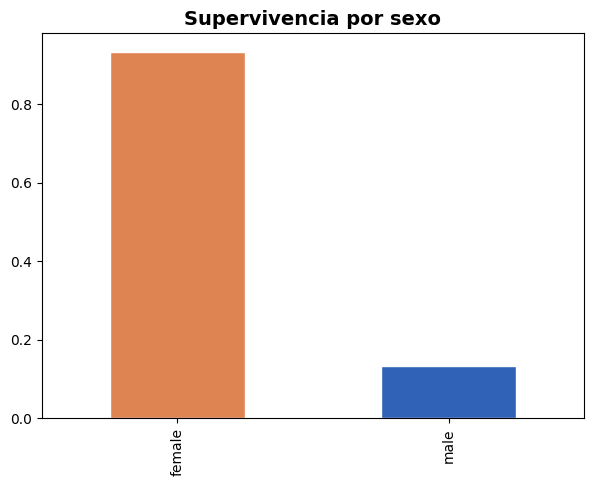

In [24]:
supervivencia_sexo = titanic_nuevo.groupby("sexo")["sobrevivio"].mean()

plt.figure(figsize=(7,5))
supervivencia_sexo.plot(
    kind="bar",
    color=["#DD8452","#3062b8"],
    edgecolor = "white",
    width = 0.5
)

plt.title("Supervivencia por sexo", fontsize=14, fontweight="bold")

plt.xlabel("")


Text(0.5, 0, '')

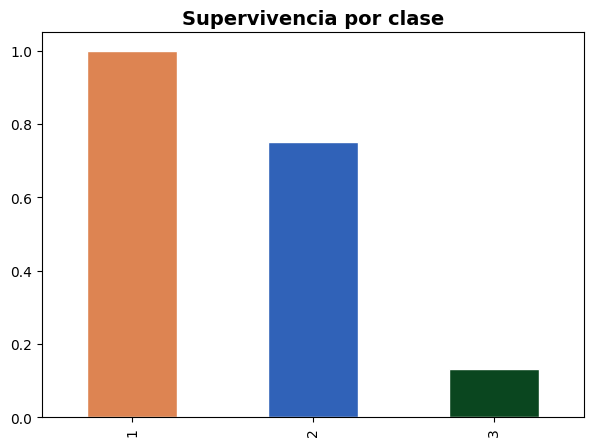

In [23]:
supervivencia_sexo = titanic_nuevo.groupby("clase")["sobrevivio"].mean()

plt.figure(figsize=(7,5))
supervivencia_sexo.plot(
    kind="bar",
    color=["#DD8452","#3062b8","#0A461F"],
    edgecolor = "white",
    width = 0.5
)

plt.title("Supervivencia por clase", fontsize=14, fontweight="bold")

plt.xlabel("")